## 1 Probability estimation

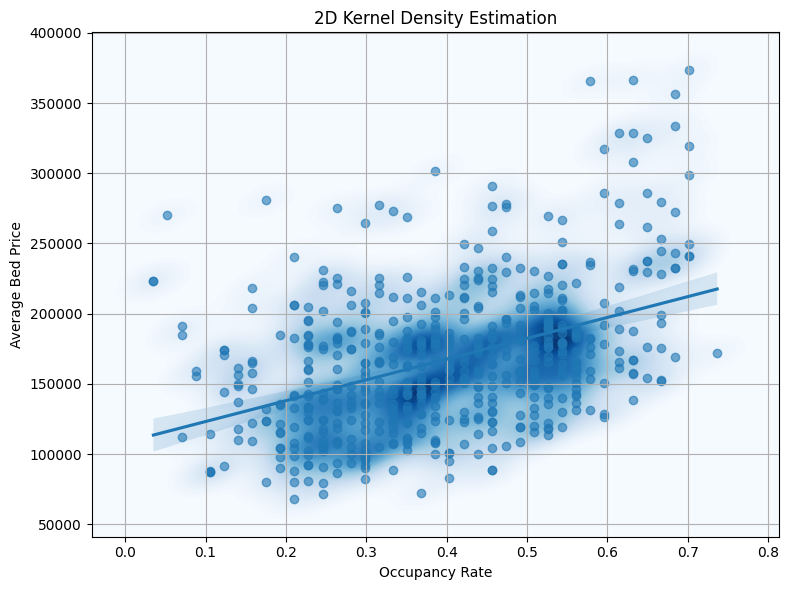

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

daily_df = pd.read_csv('data/daily_aggregated_data.csv', parse_dates=['stay_date'])

x = daily_df['occupancy_rate'].values
y = daily_df['avg_bed_rate'].values

# Stack into 2D array for KDE
xy = np.vstack([x, y])

# --- Fit the 2D kernel density estimator ---
kde = gaussian_kde(xy)

# Define grid over the space
x_grid = np.linspace(x.min(), x.max(), 100)
y_grid = np.linspace(y.min(), y.max(), 100)
X, Y = np.meshgrid(x_grid, y_grid)
positions = np.vstack([X.ravel(), Y.ravel()])

Z = kde(positions).reshape(X.shape)

# --- Plot the estimated density ---
plt.figure(figsize=(8, 6))
sns.kdeplot(
    x=x, y=y,
    fill=True, cmap='Blues', bw_adjust=0.5, # adjust for smoothing
    levels=100, thresh=0
)
sns.regplot(x='occupancy_rate', y='avg_bed_rate', data=daily_df, scatter_kws={'alpha': 0.6})
plt.title("2D Kernel Density Estimation")
plt.xlabel("Occupancy Rate")
plt.ylabel("Average Bed Price")
plt.grid(True)
plt.tight_layout()
plt.show()
